# Business Budget Analysis
## Data Analysis Portfolio Project

**Objective:** Analyse a company's financial performance across 6 departments 
over 2 years — identifying where the business is overspending, which departments 
are most profitable, and where budget variances are highest.

**Business scenario:** Mid-size technology company with 6 departments  
**Departments:** Sales, Marketing, Engineering, HR, Operations, Finance  
**Dataset:** 2 years of monthly budget vs actual data (2022–2023)  
**Tools:** Python, pandas, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'

GREEN  = '#27AE60'
RED    = '#C0392B'
BLUE   = '#2E75B6'
ORANGE = '#E67E22'
DARK   = '#1F3864'
GRAY   = '#7F8C8D'
PURPLE = '#8E44AD'

DEPT_COLORS = {
    'Sales':       '#2E75B6',
    'Marketing':   '#E67E22',
    'Engineering': '#27AE60',
    'HR':          '#8E44AD',
    'Operations':  '#C0392B',
    'Finance':     '#16A085',
}

print("Libraries loaded!")

Libraries loaded!


In [2]:
np.random.seed(42)

departments = ['Sales', 'Marketing', 'Engineering', 'HR', 'Operations', 'Finance']
months      = pd.date_range('2022-01-01', '2023-12-01', freq='MS')
month_names = [m.strftime('%b %Y') for m in months]

cost_categories = ['Salaries', 'Software', 'Marketing Spend',
                   'Travel', 'Equipment', 'Utilities', 'Training']

# Dept budgets — annual revenue target and cost base
dept_config = {
    'Sales':       {'rev_budget': 500000, 'cost_budget': 180000, 'growth': 0.08},
    'Marketing':   {'rev_budget': 200000, 'cost_budget': 150000, 'growth': 0.05},
    'Engineering': {'rev_budget': 300000, 'cost_budget': 220000, 'growth': 0.10},
    'HR':          {'rev_budget': 50000,  'cost_budget': 80000,  'growth': 0.03},
    'Operations':  {'rev_budget': 180000, 'cost_budget': 130000, 'growth': 0.06},
    'Finance':     {'rev_budget': 120000, 'cost_budget': 70000,  'growth': 0.04},
}

rows = []
for dept in departments:
    cfg = dept_config[dept]
    for i, (month, month_name) in enumerate(zip(months, month_names)):
        year = month.year

        # Monthly budget (annual / 12 with slight seasonality)
        season = 1 + 0.15 * np.sin(2 * np.pi * i / 12)
        rev_budget  = cfg['rev_budget']  / 12 * season
        cost_budget = cfg['cost_budget'] / 12 * season

        # Actual — budget + noise + growth trend
        growth_factor = 1 + cfg['growth'] * (i / 12)
        rev_actual  = rev_budget  * growth_factor * np.random.uniform(0.88, 1.18)
        cost_actual = cost_budget * growth_factor * np.random.uniform(0.90, 1.20)

        # Some depts overspend more
        if dept in ['Marketing', 'HR']:
            cost_actual *= np.random.uniform(1.02, 1.12)

        rev_actual  = round(rev_actual,  2)
        cost_actual = round(cost_actual, 2)
        rev_budget  = round(rev_budget,  2)
        cost_budget = round(cost_budget, 2)

        profit_actual = round(rev_actual  - cost_actual, 2)
        profit_budget = round(rev_budget  - cost_budget, 2)
        rev_variance  = round(rev_actual  - rev_budget,  2)
        cost_variance = round(cost_actual - cost_budget, 2)
        profit_margin = round(profit_actual / rev_actual * 100, 2) if rev_actual else 0
        budget_util   = round(cost_actual / cost_budget * 100, 2) if cost_budget else 0

        # Cost breakdown
        salary_pct = np.random.uniform(0.50, 0.65)
        remaining  = 1 - salary_pct
        other_pcts = np.random.dirichlet(np.ones(6)) * remaining

        rows.append({
            'month':          month,
            'month_name':     month_name,
            'year':           year,
            'quarter':        f"Q{month.quarter}",
            'department':     dept,
            'rev_budget':     rev_budget,
            'rev_actual':     rev_actual,
            'cost_budget':    cost_budget,
            'cost_actual':    cost_actual,
            'profit_actual':  profit_actual,
            'profit_budget':  profit_budget,
            'rev_variance':   rev_variance,
            'cost_variance':  cost_variance,
            'profit_margin':  profit_margin,
            'budget_util':    budget_util,
            'salaries':       round(cost_actual * salary_pct, 2),
            'software':       round(cost_actual * other_pcts[0], 2),
            'mktg_spend':     round(cost_actual * other_pcts[1], 2),
            'travel':         round(cost_actual * other_pcts[2], 2),
            'equipment':      round(cost_actual * other_pcts[3], 2),
            'utilities':      round(cost_actual * other_pcts[4], 2),
            'training':       round(cost_actual * other_pcts[5], 2),
        })

df = pd.DataFrame(rows)

print(f"Dataset created: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Period:       {df['month_name'].iloc[0]} to {df['month_name'].iloc[-1]}")
print(f"Departments:  {df['department'].nunique()}")
print(f"\nTotal Revenue (Actual):  ${df['rev_actual'].sum():>12,.0f}")
print(f"Total Revenue (Budget):  ${df['rev_budget'].sum():>12,.0f}")
print(f"Total Costs   (Actual):  ${df['cost_actual'].sum():>12,.0f}")
print(f"Total Costs   (Budget):  ${df['cost_budget'].sum():>12,.0f}")
print(f"Total Profit  (Actual):  ${df['profit_actual'].sum():>12,.0f}")
df.head(3)

Dataset created: 144 rows x 22 columns
Period:       Jan 2022 to Dec 2023
Departments:  6

Total Revenue (Actual):  $   2,953,200
Total Revenue (Budget):  $   2,700,000
Total Costs   (Actual):  $   1,869,872
Total Costs   (Budget):  $   1,660,000
Total Profit  (Actual):  $   1,083,327


,month,month_name,year,quarter,department,rev_budget,rev_actual,cost_budget,cost_actual,profit_actual,...,cost_variance,profit_margin,budget_util,salaries,software,mktg_spend,travel,equipment,utilities,training
0,2022-01-01,Jan 2022,2022,Q1,Sales,41666.67,41348.42,15000.00,17778.21,23570.21,...,2778.21,57.00,118.52,10841.14,1492.85,277.37,277.33,97.85,3288.78,1502.89
1,2022-02-01,Feb 2022,2022,Q1,Sales,44791.67,49257.60,16125.00,14709.49,34548.11,...,-1415.51,70.14,91.22,9494.78,2635.21,352.10,296.03,298.88,535.11,1097.39
2,2022-03-01,Mar 2022,2022,Q1,Sales,47079.33,48164.25,16948.56,16957.60,31206.65,...,9.04,64.79,100.05,10035.13,313.10,720.07,950.91,1269.05,3205.14,464.19


In [3]:
print("=" * 55)
print("DATA QUALITY CHECK")
print("=" * 55)
print(f"\nNull values:  {df.isnull().sum().sum()} — clean!")
print(f"Duplicates:   {df.duplicated().sum()} — clean!")

print(f"\n{'=' * 55}")
print("DEPARTMENT PERFORMANCE SUMMARY")
print("=" * 55)

summary = df.groupby('department').agg(
    Total_Rev_Actual  = ('rev_actual',    'sum'),
    Total_Rev_Budget  = ('rev_budget',    'sum'),
    Total_Cost_Actual = ('cost_actual',   'sum'),
    Total_Cost_Budget = ('cost_budget',   'sum'),
    Total_Profit      = ('profit_actual', 'sum'),
    Avg_Margin        = ('profit_margin', 'mean'),
    Avg_Budget_Util   = ('budget_util',   'mean'),
).round(2)

summary['Rev_Variance']  = summary['Total_Rev_Actual']  - summary['Total_Rev_Budget']
summary['Cost_Variance'] = summary['Total_Cost_Actual'] - summary['Total_Cost_Budget']
summary['Over_Budget']   = summary['Cost_Variance'] > 0

print(summary[['Total_Rev_Actual','Total_Cost_Actual',
               'Total_Profit','Avg_Margin',
               'Cost_Variance','Avg_Budget_Util']].to_string())

print(f"\n{'=' * 55}")
print("KEY FLAGS")
print("=" * 55)
over  = summary[summary['Over_Budget']].index.tolist()
under = summary[~summary['Over_Budget']].index.tolist()
print(f"\nDepts OVER budget:   {over}")
print(f"Depts UNDER budget:  {under}")
print(f"\nHighest profit margin: {summary['Avg_Margin'].idxmax()} "
      f"({summary['Avg_Margin'].max():.1f}%)")
print(f"Lowest profit margin:  {summary['Avg_Margin'].idxmin()} "
      f"({summary['Avg_Margin'].min():.1f}%)")
print(f"Most over budget:      {summary['Cost_Variance'].idxmax()} "
      f"(+${summary['Cost_Variance'].max():,.0f})")

DATA QUALITY CHECK

Null values:  0 — clean!
Duplicates:   0 — clean!

DEPARTMENT PERFORMANCE SUMMARY
             Total_Rev_Actual  Total_Cost_Actual  Total_Profit  Avg_Margin  Cost_Variance  Avg_Budget_Util
department                                                                                                
Engineering         665697.00          492928.01     172768.99       25.21       52928.09           112.28
Finance             262166.33          148189.22     113977.11       43.06        8189.26           105.99
HR                  101329.34          183183.72     -81854.38      -81.50       23183.68           114.44
Marketing           441365.98          354962.52      86403.46       18.97       54962.52           118.36
Operations          401858.10          290079.70     111778.40       27.28       30079.78           111.91
Sales              1080783.07          400529.19     680253.88       62.73       40529.19           111.36

KEY FLAGS

Depts OVER budget:   ['Enginee

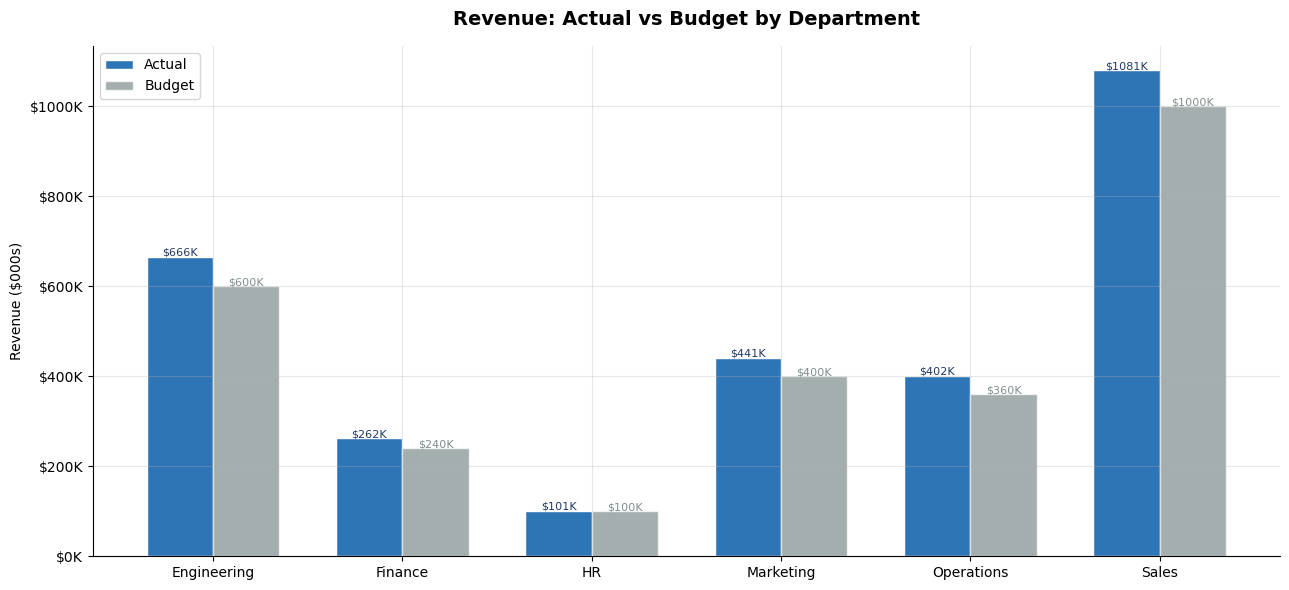

Chart 1 saved!


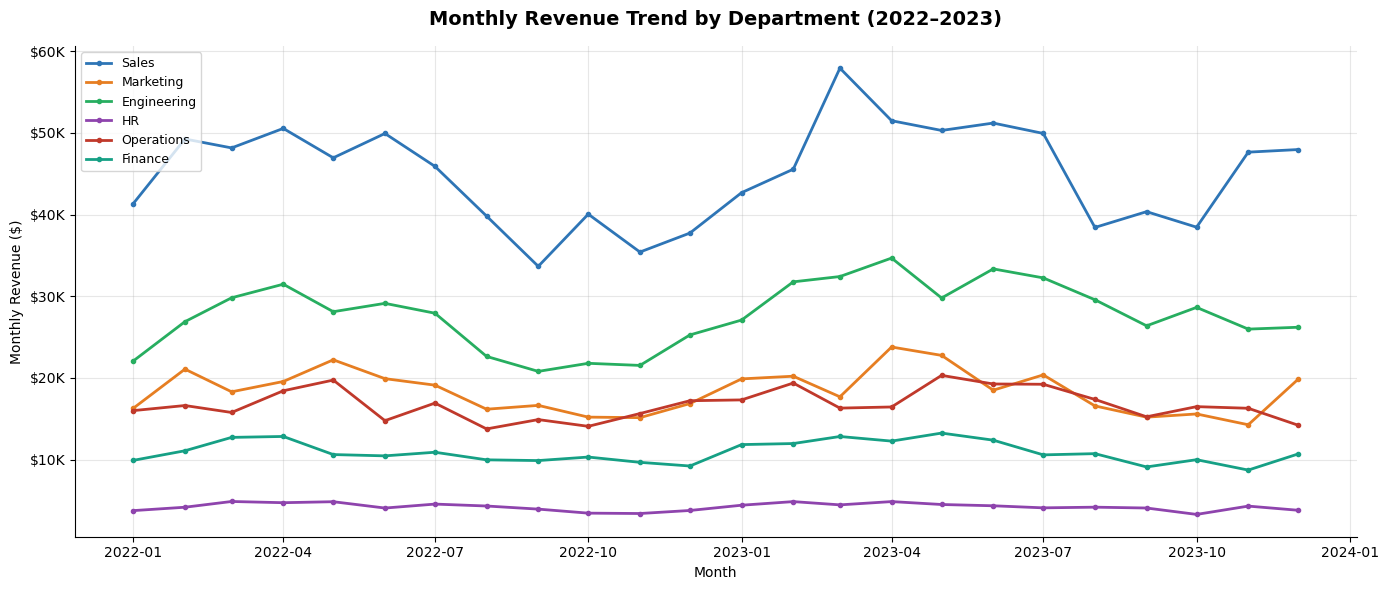

Chart 2 saved!


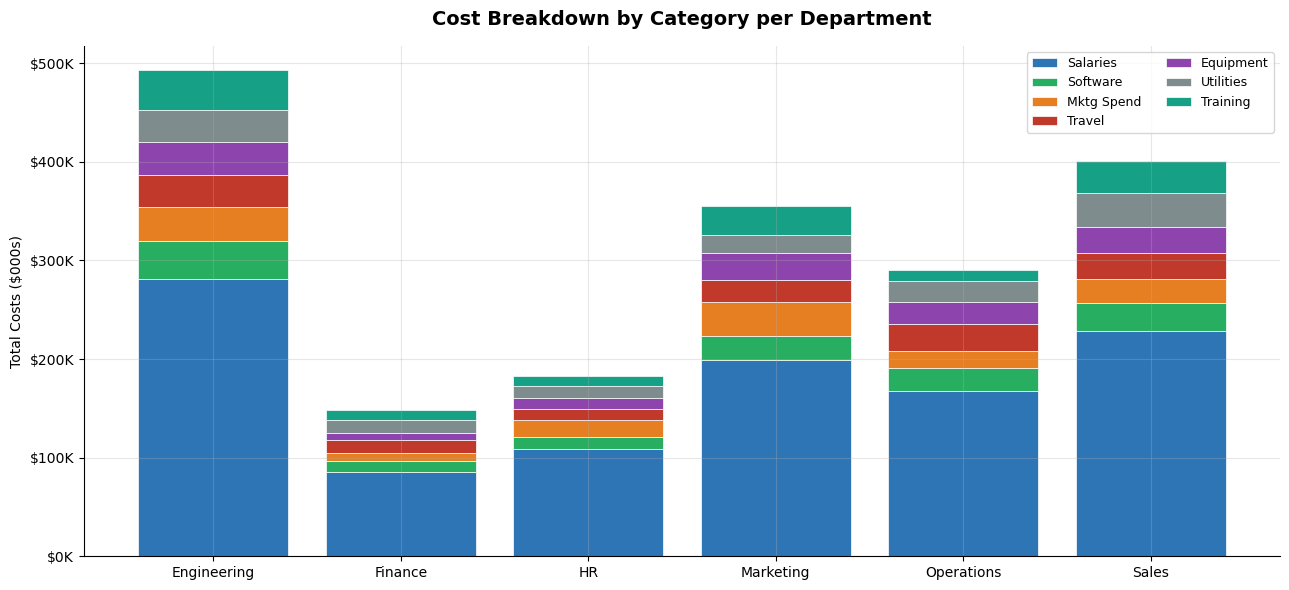

Chart 3 saved!


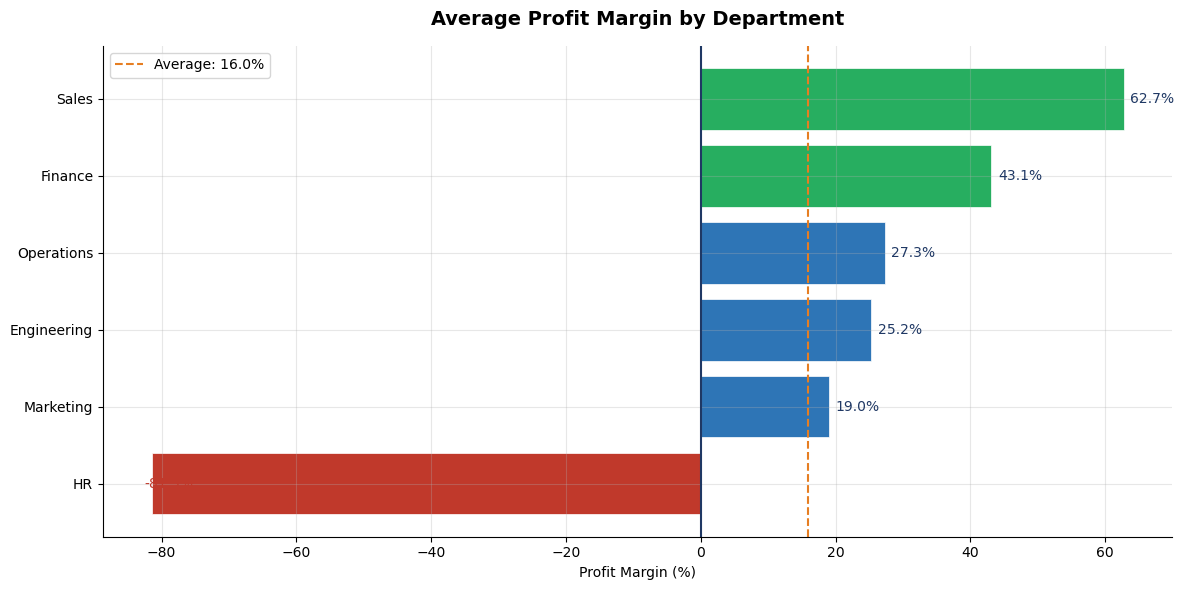

Chart 4 saved!


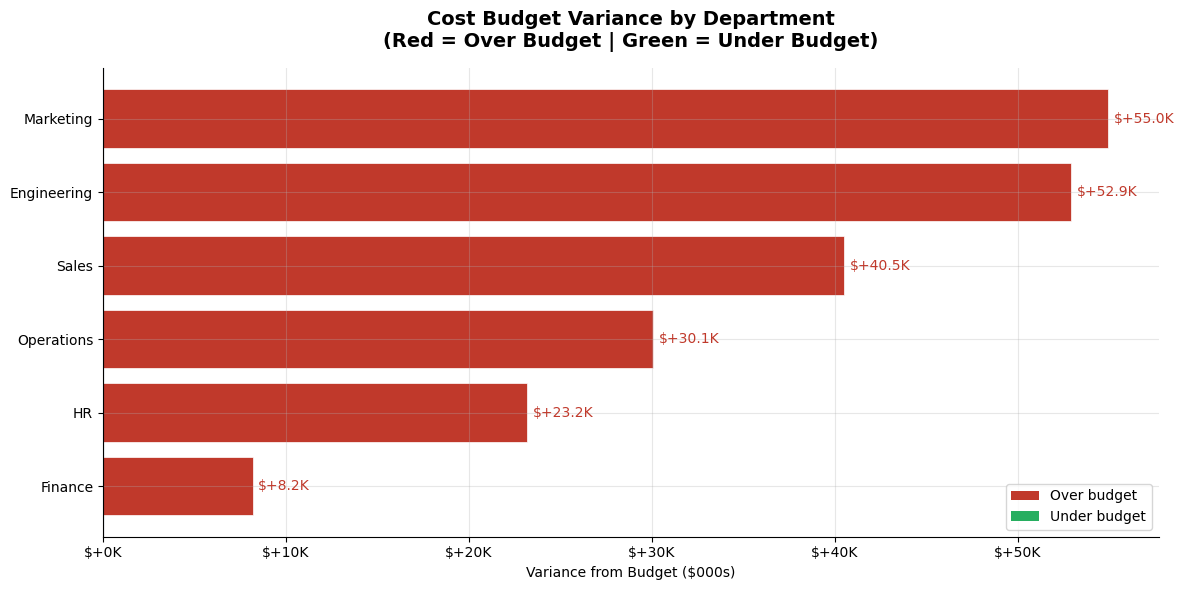

Chart 5 saved!


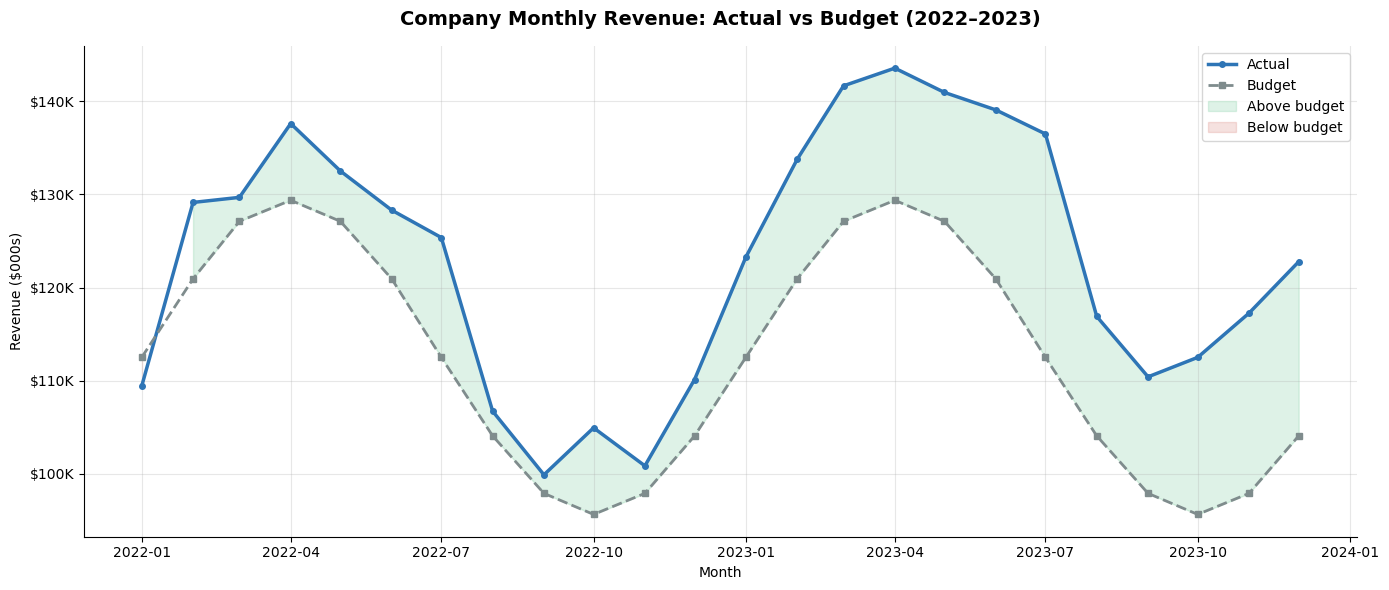

Chart 6 saved!


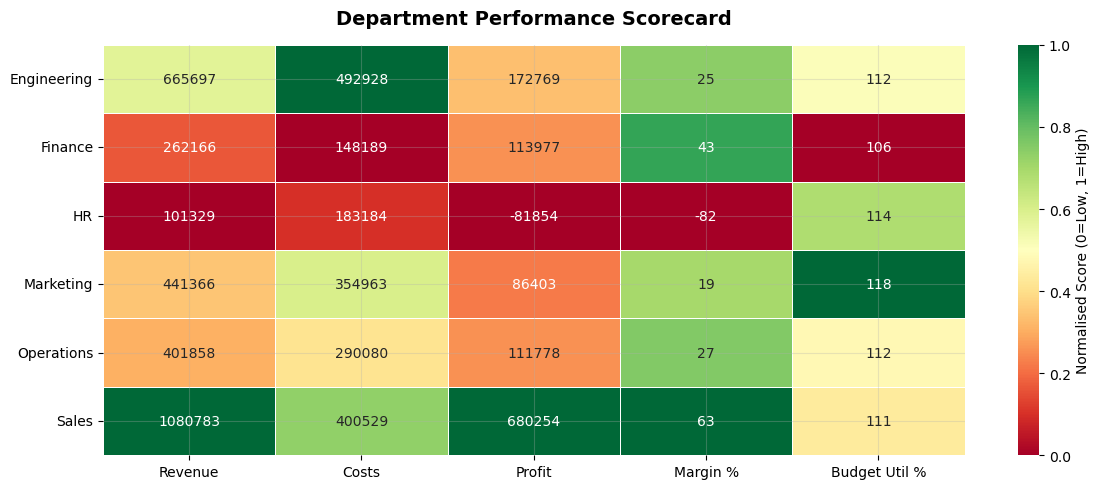

Chart 7 saved!

✅ All 7 charts generated and saved!


In [4]:
summary = df.groupby('department').agg(
    Total_Rev_Actual  = ('rev_actual',    'sum'),
    Total_Rev_Budget  = ('rev_budget',    'sum'),
    Total_Cost_Actual = ('cost_actual',   'sum'),
    Total_Cost_Budget = ('cost_budget',   'sum'),
    Total_Profit      = ('profit_actual', 'sum'),
    Avg_Margin        = ('profit_margin', 'mean'),
    Avg_Budget_Util   = ('budget_util',   'mean'),
).round(2)
summary['Cost_Variance'] = summary['Total_Cost_Actual'] - summary['Total_Cost_Budget']

# ════════════════════════════════════════════════════════
# CHART 1 — Revenue: Actual vs Budget by Department
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
x     = np.arange(len(summary))
width = 0.35
bars1 = ax.bar(x - width/2, summary['Total_Rev_Actual']/1000,
               width, label='Actual', color=BLUE, edgecolor='white')
bars2 = ax.bar(x + width/2, summary['Total_Rev_Budget']/1000,
               width, label='Budget', color=GRAY, edgecolor='white', alpha=0.7)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'${bar.get_height():.0f}K', ha='center', fontsize=8, color=DARK)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
            f'${bar.get_height():.0f}K', ha='center', fontsize=8, color=GRAY)
ax.set_title('Revenue: Actual vs Budget by Department', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.set_ylabel('Revenue ($000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('chart1_rev_actual_vs_budget.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

# ════════════════════════════════════════════════════════
# CHART 2 — Monthly Revenue Trend by Department
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
for dept in departments:
    d = df[df['department'] == dept].sort_values('month')
    ax.plot(d['month'], d['rev_actual'],
            label=dept, color=DEPT_COLORS[dept], linewidth=2, marker='o', markersize=3)
ax.set_title('Monthly Revenue Trend by Department (2022–2023)', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart2_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

# ════════════════════════════════════════════════════════
# CHART 3 — Cost Breakdown by Category (Stacked Bar)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))
cost_cols = ['salaries','software','mktg_spend','travel','equipment','utilities','training']
cost_labels = ['Salaries','Software','Mktg Spend','Travel','Equipment','Utilities','Training']
cost_colors = [BLUE, GREEN, ORANGE, RED, PURPLE, GRAY, '#16A085']
cost_by_dept = df.groupby('department')[cost_cols].sum()
bottom = np.zeros(len(cost_by_dept))
for col, label, color in zip(cost_cols, cost_labels, cost_colors):
    vals = cost_by_dept[col].values / 1000
    ax.bar(cost_by_dept.index, vals, bottom=bottom,
           label=label, color=color, edgecolor='white', linewidth=0.5)
    bottom += vals
ax.set_title('Cost Breakdown by Category per Department', pad=15)
ax.set_ylabel('Total Costs ($000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('chart3_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

# ════════════════════════════════════════════════════════
# CHART 4 — Profit Margin by Department
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
margin_df = summary['Avg_Margin'].sort_values()
colors    = [RED if v < 0 else (GREEN if v > 40 else BLUE) for v in margin_df.values]
bars = ax.barh(margin_df.index, margin_df.values,
               color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0,    color=DARK, linewidth=1.5, linestyle='-')
ax.axvline(margin_df.mean(), color=ORANGE, linewidth=1.5,
           linestyle='--', label=f'Average: {margin_df.mean():.1f}%')
for bar, val in zip(bars, margin_df.values):
    ax.text(val + (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10,
            color=RED if val < 0 else DARK)
ax.set_title('Average Profit Margin by Department', pad=15)
ax.set_xlabel('Profit Margin (%)')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_profit_margin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

# ════════════════════════════════════════════════════════
# CHART 5 — Budget Variance (Diverging Bar)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
var_df  = summary['Cost_Variance'].sort_values()
colors  = [RED if v > 0 else GREEN for v in var_df.values]
bars    = ax.barh(var_df.index, var_df.values/1000,
                  color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color=DARK, linewidth=1.5)
for bar, val in zip(bars, var_df.values/1000):
    offset = 0.3 if val >= 0 else -0.3
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'${val:+.1f}K', va='center', fontsize=10,
            color=RED if val > 0 else GREEN)
ax.set_title('Cost Budget Variance by Department\n(Red = Over Budget | Green = Under Budget)',
             pad=15)
ax.set_xlabel('Variance from Budget ($000s)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:+.0f}K'))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=RED,   label='Over budget'),
                   Patch(facecolor=GREEN, label='Under budget')])
plt.tight_layout()
plt.savefig('chart5_budget_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

# ════════════════════════════════════════════════════════
# CHART 6 — Monthly Actual vs Budget Revenue (Company Total)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
monthly = df.groupby('month').agg(
    rev_actual = ('rev_actual',  'sum'),
    rev_budget = ('rev_budget',  'sum'),
).reset_index()
ax.plot(monthly['month'], monthly['rev_actual']/1000,
        color=BLUE,  linewidth=2.5, marker='o', markersize=4, label='Actual')
ax.plot(monthly['month'], monthly['rev_budget']/1000,
        color=GRAY,  linewidth=2,   marker='s', markersize=4,
        linestyle='--', label='Budget')
ax.fill_between(monthly['month'],
                monthly['rev_actual']/1000,
                monthly['rev_budget']/1000,
                where=monthly['rev_actual'] >= monthly['rev_budget'],
                alpha=0.15, color=GREEN, label='Above budget')
ax.fill_between(monthly['month'],
                monthly['rev_actual']/1000,
                monthly['rev_budget']/1000,
                where=monthly['rev_actual'] < monthly['rev_budget'],
                alpha=0.15, color=RED, label='Below budget')
ax.set_title('Company Monthly Revenue: Actual vs Budget (2022–2023)', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('chart6_monthly_actual_vs_budget.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

# ════════════════════════════════════════════════════════
# CHART 7 — Department Performance Heatmap (Scorecard)
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
scorecard = summary[['Total_Rev_Actual','Total_Cost_Actual',
                      'Total_Profit','Avg_Margin','Avg_Budget_Util']].copy()
scorecard.columns = ['Revenue','Costs','Profit','Margin %','Budget Util %']
scorecard_norm = (scorecard - scorecard.min()) / (scorecard.max() - scorecard.min())
sns.heatmap(scorecard_norm, ax=ax, cmap='RdYlGn', annot=scorecard.round(0),
            fmt='.0f', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalised Score (0=Low, 1=High)'})
ax.set_title('Department Performance Scorecard', pad=15)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart7_scorecard_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved!")

print("\n✅ All 7 charts generated and saved!")

## Key Business Insights

### 1. Every department exceeded its cost budget
All 6 departments overspent in 2022–2023. Marketing was the biggest 
overspender at +$54,963 above budget — a clear signal that campaign 
spending lacks proper controls.

### 2. HR is operating at a loss (-81.5% margin)
HR generated only $101K in revenue against $183K in costs — resulting 
in a negative profit margin of -81.5%. The business must review whether 
HR's cost structure is sustainable or whether shared services can reduce overhead.

### 3. Sales is the company's profit engine (62.7% margin)
Sales generated $680K in profit on $1.08M revenue — the strongest 
margin of all departments. Any budget cuts should protect Sales 
headcount and tooling as a priority.

### 4. Engineering is the most budget-hungry department
Engineering consumed $492K in costs — the highest of any department — 
driven primarily by salaries. However its 25% profit margin suggests 
the investment is generating returns.

### 5. Company revenue beat budget by $253K overall

Despite all departments overspending on costs, total actual revenue 
of $2.95M exceeded the $2.7M budget by 9.4% — indicating strong 
commercial performance offsetting cost overruns.

### 6. Salaries dominate costs across all departments
The cost breakdown shows salaries consistently represent 50–65% of 
every department's total costs. Any meaningful cost reduction programme 
must address headcount or compensation structure.

### 7. Monthly revenue trend shows healthy growth
The monthly trend chart shows actual revenue consistently tracking 
above budget from mid-2022 onward — with the gap widening into 2023, 
confirming the business is on a strong growth trajectory.

In [5]:
print("=" * 55)
print("  BUSINESS BUDGET ANALYSIS — COMPLETE")
print("=" * 55)
print(f"\n  Dataset:     144 rows | 6 departments | 24 months")
print(f"  Period:      Jan 2022 to Dec 2023")
print(f"\n  Financial Summary:")
print(f"    Total Revenue (Actual):  ${df['rev_actual'].sum():>10,.0f}")
print(f"    Total Revenue (Budget):  ${df['rev_budget'].sum():>10,.0f}")
print(f"    Total Costs   (Actual):  ${df['cost_actual'].sum():>10,.0f}")
print(f"    Total Costs   (Budget):  ${df['cost_budget'].sum():>10,.0f}")
print(f"    Total Profit  (Actual):  ${df['profit_actual'].sum():>10,.0f}")
print(f"\n  Key Flags:")
print(f"    Best margin dept:   Sales (62.7%)")
print(f"    Loss-making dept:   HR (-81.5%)")
print(f"    Biggest overspend:  Marketing (+$54,963)")
print(f"\n  Charts saved:")
for i, name in enumerate([
    "rev_actual_vs_budget",   "monthly_revenue_trend",
    "cost_breakdown",         "profit_margin",
    "budget_variance",        "monthly_actual_vs_budget",
    "scorecard_heatmap"
], 1):
    print(f"    chart{i}_{name}.png")
print("\n  Ready for GitHub upload!")
print("=" * 55)

  BUSINESS BUDGET ANALYSIS — COMPLETE

  Dataset:     144 rows | 6 departments | 24 months
  Period:      Jan 2022 to Dec 2023

  Financial Summary:
    Total Revenue (Actual):  $ 2,953,200
    Total Revenue (Budget):  $ 2,700,000
    Total Costs   (Actual):  $ 1,869,872
    Total Costs   (Budget):  $ 1,660,000
    Total Profit  (Actual):  $ 1,083,327

  Key Flags:
    Best margin dept:   Sales (62.7%)
    Loss-making dept:   HR (-81.5%)
    Biggest overspend:  Marketing (+$54,963)

  Charts saved:
    chart1_rev_actual_vs_budget.png
    chart2_monthly_revenue_trend.png
    chart3_cost_breakdown.png
    chart4_profit_margin.png
    chart5_budget_variance.png
    chart6_monthly_actual_vs_budget.png
    chart7_scorecard_heatmap.png

  Ready for GitHub upload!
